In [1]:
import bw2io as bi
import bw2data as bd
import bw2calc as bc
import pandas as pd
import brightway2 as bw

In [2]:
bd.projects.set_current('Practicas')

In [3]:
bw.bw2setup()

Biosphere database already present!!! No setup is needed


In [4]:
list(bd.databases)

['biosphere3', 'BAFU-2025 Version 2 - openLCA 2026-03-09']

In [5]:
db = bd.Database("BAFU-2025 Version 2 - openLCA 2026-03-09")

In [6]:
# Busca coincidencias de forma general
busqueda = [act for act in db if "bottle" in act['name'].lower()]
print(f"Se encontraron {len(busqueda)} procesos.")

if len(busqueda) > 0:
    botella_1 = busqueda[0]
    print(f"Seleccionado: {botella_1['name']}")
else:
    print("No se encontró nada. Intenta imprimir los nombres:")
    for act in list(db)[:5]: 
        print(act['name'])

Se encontraron 1 procesos.
Seleccionado: polyethylene terephthalate granulate bottle grade at plant


In [7]:
terminos_vidrio = ["glass", "packaging", "container", "beverage"]
coincidencias = [act for act in db if any(t in act['name'].lower() for t in terminos_vidrio)]

# Imprime los primeros
for i, act in enumerate(coincidencias[:5]):
    print(f"[{i}] {act['name']} ({act['unit']})")

[0] xx recycling glass (kilogram)
[1] aluminiumtrihydroxide-acrylic glass at plant (kilogram)
[2] glass fibre-reinforced polymer panel transport tr->ch (square meter)
[3] disposal glass fibre-reinforced polymer panel polyester resin as building waste (square meter)
[4] laminated safety glass at plant (square meter)


In [8]:
# Selección directa por el nombre exacto
botella_2 = [act for act in db if "packaging glass green at plant" in act['name']][0]

print(f"Comparación lista:")
print(f"1. {botella_1['name']} ({botella_1['unit']})")
print(f"2. {botella_2['name']} ({botella_2['unit']})")

Comparación lista:
1. polyethylene terephthalate granulate bottle grade at plant (kilogram)
2. xx packaging glass green at plant (kilogram)


In [9]:
funcional_unit = [
    {botella_1: 0.025}, # 25g de PET
    {botella_2: 0.400}  # 400g de Vidrio
]

In [10]:
# Esto imprimirá todos los métodos que tengan "IPCC" en el nombre
metodos_disponibles=[m for m in bw.methods if "IPCC" in str(m)]
metodos_disponibles[:5] 

[('IPCC 2013 no LT',
  'climate change no LT',
  'global temperature change potential (GTP100) no LT'),
 ('IPCC 2013 no LT',
  'climate change no LT',
  'global temperature change potential (GTP20) no LT'),
 ('IPCC 2013 no LT',
  'climate change no LT',
  'global warming potential (GWP100) no LT'),
 ('IPCC 2013 no LT',
  'climate change no LT',
  'global warming potential (GWP20) no LT'),
 ('IPCC 2013',
  'climate change',
  'global temperature change potential (GTP100)')]

In [11]:
# Seleccionamos el método de la lista 
metodo_carbono = ('IPCC 2021', 'climate change', 'global warming potential (GWP100)')

# Definimos nuestras botellas 
botella_pet = [act for act in db if "polyethylene terephthalate granulate bottle grade" in act['name']][0]
botella_vidrio = [act for act in db if "packaging glass green at plant" in act['name']][0]

In [12]:
# Cálculo para PET
lca_pet = bw.LCA({botella_pet: 0.025}, metodo_carbono)
lca_pet.lci()
lca_pet.lcia()
res_pet = lca_pet.score

# Cálculo para Vidrio
lca_vidrio = bw.LCA({botella_vidrio: 0.400}, metodo_carbono)
lca_vidrio.lci()
lca_vidrio.lcia()
res_vidrio = lca_vidrio.score

print("--- RESULTADOS (kg CO2-eq) ---")
print(f"Botella PET (25g):    {res_pet:.4f}")
print(f"Botella Vidrio (400g): {res_vidrio:.4f}")

if res_pet < res_vidrio:
    print(f"\nEl PET tiene un impacto {(res_vidrio/res_pet):.1f} veces menor que el vidrio en esta etapa.")
else:
    print(f"\nEl Vidrio es sorprendentemente mejor por un factor de {(res_pet/res_vidrio):.1f}.")

--- RESULTADOS (kg CO2-eq) ---
Botella PET (25g):    0.0636
Botella Vidrio (400g): 0.1029

El PET tiene un impacto 1.6 veces menor que el vidrio en esta etapa.


In [13]:
# Vamos a ver qué métodos hay disponibles que contengan 'ReCiPe'
metodos_disponibles = [m for m in bw.methods if 'ReCiPe' in str(m)]
metodos_disponibles[:5] 

[('ReCiPe 2016 v1.03, endpoint (E) no LT',
  'ecosystem quality no LT',
  'acidification: terrestrial no LT'),
 ('ReCiPe 2016 v1.03, endpoint (E) no LT',
  'ecosystem quality no LT',
  'climate change: freshwater ecosystems no LT'),
 ('ReCiPe 2016 v1.03, endpoint (E) no LT',
  'ecosystem quality no LT',
  'climate change: terrestrial ecosystems no LT'),
 ('ReCiPe 2016 v1.03, endpoint (E) no LT',
  'ecosystem quality no LT',
  'ecotoxicity: freshwater no LT'),
 ('ReCiPe 2016 v1.03, endpoint (E) no LT',
  'ecosystem quality no LT',
  'ecotoxicity: marine no LT')]

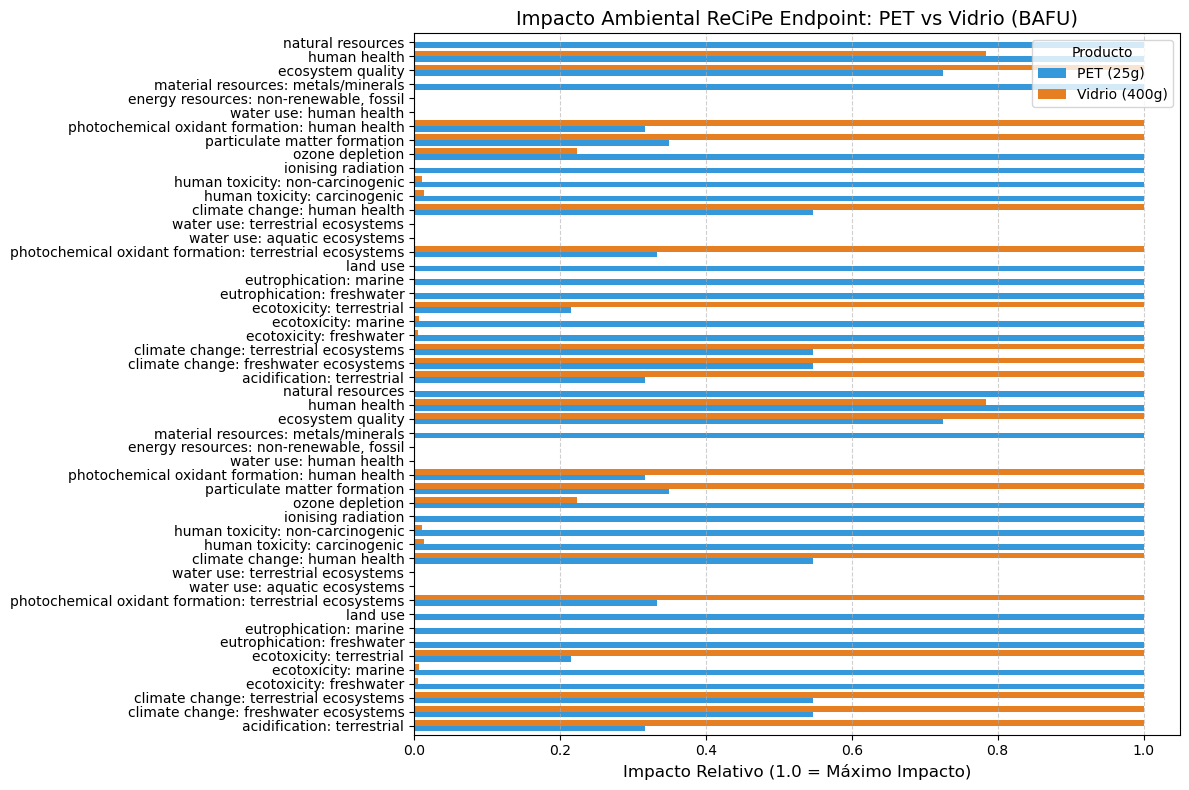

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Ftramos exactamente por el nombre que aparece en la lista
recipe_endpoints = [m for m in bw.methods if 'ReCiPe 2016 v1.03' in m[0] and 'endpoint (E)' in m[0]]

if not recipe_endpoints:
    print("No se encontraron métodos. Revisa si el nombre tiene espacios extra.")
else:
    #Configurar el MultiLCA
    setup_name = "comparativa_botellas_endpoints"
    bw.calculation_setups[setup_name] = {
        'inv': [{botella_pet: 0.025}, {botella_vidrio: 0.400}],
        'ia': recipe_endpoints
    }
    
    mlca = bw.MultiLCA(setup_name)
    
    # Crear DataFrame y limpiar nombres para la gráfica
    # Usamos el último elemento de la tupla (el nombre del impacto)
    col_names = [m[2].replace(' no LT', '') for m in recipe_endpoints]
    df = pd.DataFrame(mlca.results, columns=col_names, index=['PET (25g)', 'Vidrio (400g)']).T
    
    # Normalizar (0 a 1)
    df_norm = df.div(df.max(axis=1), axis=0)
    
    # Graficar
    ax = df_norm.plot(kind='barh', figsize=(12, 8), color=['#3498db', '#e67e22'], width=0.8)
    plt.title('Impacto Ambiental ReCiPe Endpoint: PET vs Vidrio (BAFU)', fontsize=14)
    plt.xlabel('Impacto Relativo (1.0 = Máximo Impacto)', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.legend(title='Producto', loc='best')
    plt.tight_layout()
    plt.show()

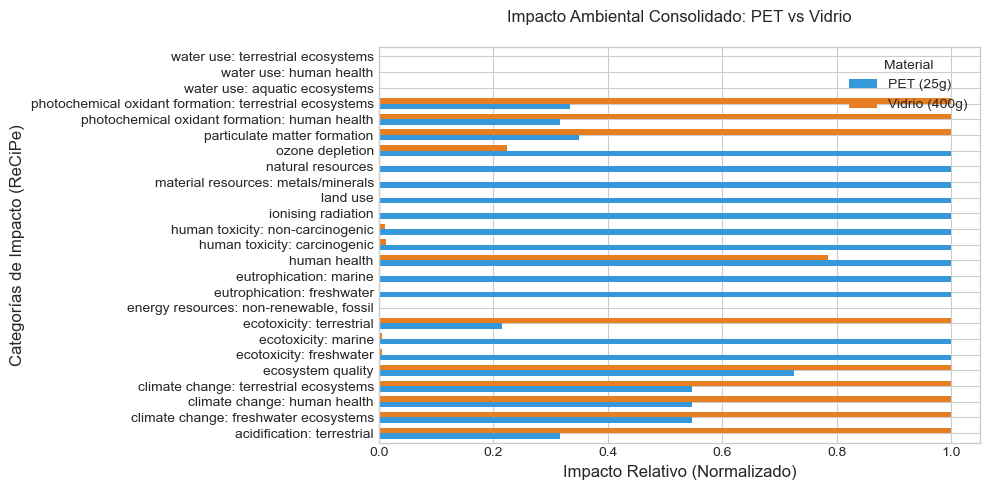

In [38]:
# Esto consolida, por ejemplo, los dos 'Climate Change' en uno solo.
df_grouped = df.groupby(df.index).sum()

# Volvemos a normalizar para que la comparación sea clara
df_grouped_norm = df_grouped.div(df_grouped.max(axis=1), axis=0)

# Graficamos de nuevo
plt.style.use('seaborn-v0_8-whitegrid') # Un estilo más limpio
ax = df_grouped_norm.plot(kind='barh', figsize=(10, 5), color=['#3498db', '#e67e22'], width=.7)

plt.title('Impacto Ambiental Consolidado: PET vs Vidrio', fontsize=12, pad=18)
plt.xlabel('Impacto Relativo (Normalizado)', fontsize=12)
plt.ylabel('Categorías de Impacto (ReCiPe)', fontsize=12)
plt.legend(title='Material', labels=['PET (25g)', 'Vidrio (400g)'], loc='upper right')

plt.tight_layout()
plt.show()